In [1]:
# This notebook uses ImageDataGenerator + flow_from_dataframe(class_mode='multi_output'),
# which were REMOVED in Keras 3 (the default in current Colab).
# Switching TensorFlow back to the stable Keras 2 API lets the old code run unchanged.
# MUST run before importing tensorflow/keras anywhere.
!pip install -q tf_keras
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 16.2 MB/s eta 0:00:00


In [3]:
# Legacy Kaggle creds via Colab Secrets (🔑): add KAGGLE_USERNAME and KAGGLE_KEY
# from Kaggle -> Settings -> API -> "Create Legacy API Key" (the kaggle.json values).
import os
from google.colab import userdata

os.environ.pop("KAGGLE_API_TOKEN", None)   # clear any stale KGAT token
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME").strip()
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY").strip()

In [4]:
# --unzip extracts in place; -p sets the destination. If this 403s, verify the slug:
#   !kaggle datasets list -s utkface
!kaggle datasets download -d jangedoo/utkface-new --unzip -p /content

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:03<00:00, 95.7MB/s]



In [5]:
import os
import numpy as np
import pandas as pd

In [7]:
# UTKFace images land here after extraction.
# Sanity check: os.listdir(folder_path)[:5] should show files like '25_0_0_2017...jpg'
folder_path = '/content/utkface_aligned_cropped/UTKFace'

In [8]:
# UTKFace filename format:  age_gender_race_datetime.jpg
#   split('_')[0] -> age    (integer, in years)
#   split('_')[1] -> gender (0 = male, 1 = female)
age = []
gender = []
img_path = []
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

In [9]:
len(age)

23708

In [10]:
df = pd.DataFrame({'age': age, 'gender': gender, 'img': img_path})

In [11]:
print(df.shape)
df.head()

(23708, 3)


,age,gender,img
0,27,1,27_1_0_20170116220503099.jpg.chip.jpg
1,72,0,72_0_1_20170117165211936.jpg.chip.jpg
2,60,0,60_0_0_20170120221103380.jpg.chip.jpg
3,36,0,36_0_3_20170119201947413.jpg.chip.jpg
4,30,1,30_1_0_20170104165921257.jpg.chip.jpg


In [12]:
# Shuffle once with a fixed seed, then take first 20k for train, remainder for test.
train_df = df.sample(frac=1, random_state=0).iloc[:20000]
test_df  = df.sample(frac=1, random_state=0).iloc[20000:]

print("train:", train_df.shape, "| test:", test_df.shape)

train: (20000, 3) | test: (3708, 3)


In [13]:
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(dframe, training):
    paths   = folder_path + '/' + dframe['img'].values
    ages    = dframe['age'].values.astype('float32')
    genders = dframe['gender'].values.astype('float32')

    ds = tf.data.Dataset.from_tensor_slices((paths, ages, genders))

    def load(path, age, gender):
        img = tf.io.read_file(path)
        img = tf.io.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [200, 200]) / 255.0
        return img, {'age': age, 'gender': gender}   # keys match the output layer names

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(1000)
        ds = ds.map(lambda img, y: (tf.image.random_flip_left_right(img), y),
                    num_parallel_calls=AUTOTUNE)

    return ds.batch(32).prefetch(AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
test_ds  = make_dataset(test_df,  training=False)

In [14]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [15]:
# Frozen ResNet50 feature extractor (ImageNet weights, no top classifier).
resnet = ResNet50(include_top=False, input_shape=(200, 200, 3))
resnet.trainable = False

# Shared backbone features, flattened into a vector.
output = resnet.layers[-1].output
flatten = Flatten()(output)

# --- Age branch (regression) ---
dense1 = Dense(512, activation='relu')(flatten)
dense3 = Dense(512, activation='relu')(dense1)
output1 = Dense(1, activation='linear', name='age')(dense3)    # linear -> continuous age

# --- Gender branch (binary classification) ---
dense2 = Dense(512, activation='relu')(flatten)
dense4 = Dense(512, activation='relu')(dense2)
output2 = Dense(1, activation='sigmoid', name='gender')(dense4)  # sigmoid -> 0..1 probability

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
model = Model(inputs=resnet.input, outputs=[output1, output2])

In [17]:
# Age uses MAE (mean absolute error, in years); gender uses binary crossentropy.
# loss_weights balances their scales: gender loss (~0.6) is tiny next to age MAE (~10-40),
# so gender is up-weighted 99x, otherwise the model would basically ignore it.
model.compile(optimizer='adam',
              loss={'age': 'mae', 'gender': 'binary_crossentropy'},
              metrics={'age': 'mae', 'gender': 'accuracy'},
              loss_weights={'age': 1, 'gender': 99})

In [20]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 91s 118ms/step - age_loss: 15.2291 - age_mae: 15.2291 - gender_accuracy: 0.5199 - gender_loss: 0.8333 - loss: 97.7276 - val_age_loss: 13.6568 - val_age_mae: 13.6554 - val_gender_accuracy: 0.5148 - val_gender_loss: 0.6927 - val_loss: 82.2335
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - age_loss: 13.8111 - age_mae: 13.8111 - gender_accuracy: 0.5234 - gender_loss: 0.6961 - loss: 82.7249 - val_age_loss: 12.8720 - val_age_mae: 12.8697 - val_gender_accuracy: 0.5148 - val_gender_loss: 0.6927 - val_loss: 81.4475
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 110ms/step - age_loss: 12.9786 - age_mae: 12.9786 - gender_accuracy: 0.5241 - gender_loss: 0.6921 - loss: 81.4958 - val_age_loss: 14.5863 - val_age_mae: 14.5858 - val_gender_accuracy: 0.5148 - val_gender_loss: 0.6927 - val_loss: 83.1672
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - age_loss: 12.4898 - age_mae: 12.4898 - gender_accuracy: 0.5241 - gender_loss: 0.6921 - loss: 81.0032

Saving test_image(1).png to test_image(1).png


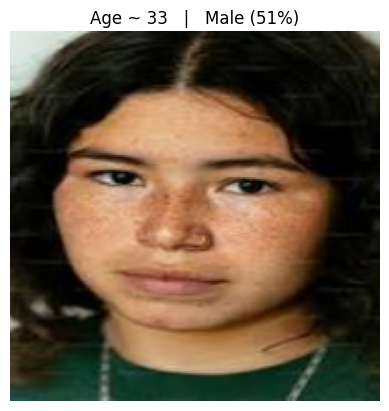

Predicted age:    32.9 years
Predicted gender: Male  (raw sigmoid = 0.486)


In [21]:
# ---- Predict age + gender from an uploaded image (matches tf.data preprocessing) ----
import numpy as np
import tensorflow as tf
from google.colab import files
import matplotlib.pyplot as plt

# 1. Upload
uploaded = files.upload()
img_name = next(iter(uploaded))

# 2. Preprocess EXACTLY like training: decode_jpeg -> resize 200x200 -> /255
raw = tf.io.read_file(img_name)
img = tf.io.decode_jpeg(raw, channels=3)
img = tf.image.resize(img, [200, 200]) / 255.0
img_batch = tf.expand_dims(img, axis=0)          # (1, 200, 200, 3)

# 3. Predict — model outputs [age, gender]
age_pred, gender_pred = model.predict(img_batch, verbose=0)
predicted_age = float(age_pred[0][0])
gender_prob   = float(gender_pred[0][0])         # 0..1

# UTKFace: 0 = Male, 1 = Female
predicted_gender = "Female" if gender_prob > 0.5 else "Male"
confidence = gender_prob if gender_prob > 0.5 else 1 - gender_prob

# 4. Show
plt.imshow(img.numpy())
plt.axis('off')
plt.title(f"Age ~ {predicted_age:.0f}   |   {predicted_gender} ({confidence*100:.0f}%)")
plt.show()
print(f"Predicted age:    {predicted_age:.1f} years")
print(f"Predicted gender: {predicted_gender}  (raw sigmoid = {gender_prob:.3f})")